# ⭐ Notebook 04 — Análise de Reviews e Satisfação do Cliente (Olist)

**Objetivo:** Investigar a satisfação do cliente, o impacto dos atrasos logísticos e do frete nas avaliações, e realizar testes estatísticos (Chi-Square e Mann-Whitney U) juntamente com análise dos comentários.

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento e Preparação dos Dados

In [2]:
reviews = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(DATA_DIR, 'product_category_name_translation.csv'))

# Converter datas
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Calcular atraso em dias (positivo = atrasado, negativo = adiantado)
orders_deliv = orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date']).copy()
orders_deliv['delay_days'] = (orders_deliv['order_delivered_customer_date'] - orders_deliv['order_estimated_delivery_date']).dt.total_seconds() / (24*3600)
orders_deliv['is_late'] = orders_deliv['delay_days'] > 0

df_rev = reviews.merge(orders_deliv, on='order_id', how='inner')
print(f"✓ Shape total da análise de reviews: {df_rev.shape}")


✓ Shape total da análise de reviews: (96359, 16)


## 3. Distribuição dos Scores de Avaliação

  ⭐ Nota 1: 11.5%
  ⭐ Nota 2: 3.2%
  ⭐ Nota 3: 8.2%
  ⭐ Nota 4: 19.3%
  ⭐ Nota 5: 57.8%


/run/user/1000/snap.antigravity/ipykernel_43886/858025330.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette='magma')


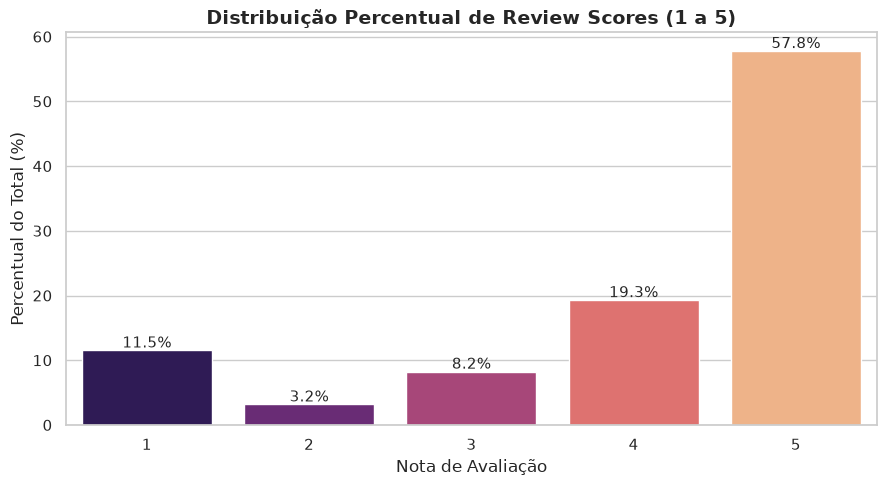

In [3]:
score_counts = reviews['review_score'].value_counts(normalize=True).sort_index() * 100

for score, pct in score_counts.items():
    print(f"  ⭐ Nota {score}: {pct:.1f}%")

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette='magma')
plt.title('Distribuição Percentual de Review Scores (1 a 5)', fontsize=14, fontweight='bold')
plt.xlabel('Nota de Avaliação')
plt.ylabel('Percentual do Total (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_review_score_distribution.png'))
plt.show()


## 4. Impacto dos Atrasos de Entrega na Nota

/run/user/1000/snap.antigravity/ipykernel_43886/1652201296.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_score_by_delay.index, y=avg_score_by_delay.values, palette='Reds_r')


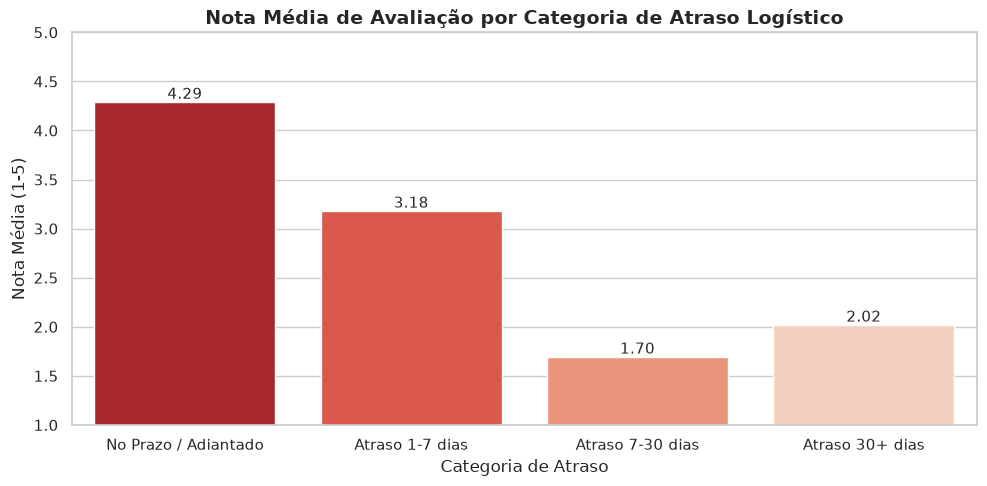

In [4]:
# Agrupar por categoria de entrega
def categorize_delay(days):
    if days <= 0:
        return 'No Prazo / Adiantado'
    elif days <= 7:
        return 'Atraso 1-7 dias'
    elif days <= 30:
        return 'Atraso 7-30 dias'
    else:
        return 'Atraso 30+ dias'

df_rev['delay_category'] = df_rev['delay_days'].apply(categorize_delay)
cat_order = ['No Prazo / Adiantado', 'Atraso 1-7 dias', 'Atraso 7-30 dias', 'Atraso 30+ dias']
avg_score_by_delay = df_rev.groupby('delay_category')['review_score'].mean().reindex(cat_order)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=avg_score_by_delay.index, y=avg_score_by_delay.values, palette='Reds_r')
plt.title('Nota Média de Avaliação por Categoria de Atraso Logístico', fontsize=14, fontweight='bold')
plt.xlabel('Categoria de Atraso')
plt.ylabel('Nota Média (1-5)')
plt.ylim(1, 5)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_delivery_delay_vs_score.png'))
plt.show()


## 5. Testes Estatísticos (Chi-Square e Mann-Whitney U)

In [5]:
from scipy import stats

# Correlação de Pearson
corr_delay_score = df_rev['delay_days'].corr(df_rev['review_score'])
print(f"📊 Correlação entre Dias de Atraso e Nota de Review: {corr_delay_score:.4f}")

# Teste Mann-Whitney U (No prazo vs Atrasado)
on_time_scores = df_rev[~df_rev['is_late']]['review_score']
late_scores = df_rev[df_rev['is_late']]['review_score']

u_stat, p_val_mw = stats.mannwhitneyu(on_time_scores, late_scores, alternative='two-sided')
print(f"🧪 Teste Mann-Whitney U (No Prazo vs Atrasado): p-value = {p_val_mw:.4e}")

# Teste Chi-Square
contingency_table = pd.crosstab(df_rev['is_late'], df_rev['review_score'])
chi2, p_val_chi2, dof, ex = stats.chi2_contingency(contingency_table)
print(f"🧪 Teste Chi-Square (Atrasado × Review Score): p-value = {p_val_chi2:.4e}")

print("\n✅ CONCLUSÃO: O atraso logístico afeta a satisfação do cliente de forma ESTATISTICAMENTE SIGNIFICATIVA (p < 0.001)!")


📊 Correlação entre Dias de Atraso e Nota de Review: -0.2664
🧪 Teste Mann-Whitney U (No Prazo vs Atrasado): p-value = 0.0000e+00
🧪 Teste Chi-Square (Atrasado × Review Score): p-value = 0.0000e+00

✅ CONCLUSÃO: O atraso logístico afeta a satisfação do cliente de forma ESTATISTICAMENTE SIGNIFICATIVA (p < 0.001)!


## 6. Análise de Comentários Textuais

In [6]:
has_comment = reviews['review_comment_message'].notnull()
print(f"💬 Avaliações COM comentário escrito: {has_comment.sum():,} ({has_comment.mean()*100:.1f}%)")
print(f"😶 Avaliações SEM comentário escrito: {(~has_comment).sum():,} ({(~has_comment).mean()*100:.1f}%)")

# Palavras mais comuns em reviews nota 1 vs nota 5
neg_comments = reviews[reviews['review_score'] == 1]['review_comment_message'].dropna().str.lower()
pos_comments = reviews[reviews['review_score'] == 5]['review_comment_message'].dropna().str.lower()

from collections import Counter
import re

def get_top_words(series, n=10):
    words = []
    stopwords = set(['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'nao', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'quando', 'muito', 'nos', 'já', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'você', 'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'numa', 'cujos', 'quais', 'ser', 'produto', 'entrega'])
    for text in series:
        tokens = re.findall(r'\b[a-záàâãéêíóôõúç]{3,}\b', text)
        words.extend([w for w in tokens if w not in stopwords])
    return Counter(words).most_common(n)

print("\n🔴 Top 10 Palavras em Reviews Negativos (Nota 1):")
for word, count in get_top_words(neg_comments, 10):
    print(f"  - {word}: {count:,} vezes")

print("\n🟢 Top 10 Palavras em Reviews Positivos (Nota 5):")
for word, count in get_top_words(pos_comments, 10):
    print(f"  - {word}: {count:,} vezes")


💬 Avaliações COM comentário escrito: 40,977 (41.3%)
😶 Avaliações SEM comentário escrito: 58,247 (58.7%)

🔴 Top 10 Palavras em Reviews Negativos (Nota 1):
  - não: 6,255 vezes
  - recebi: 2,783 vezes
  - comprei: 1,560 vezes
  - ainda: 1,181 vezes
  - veio: 1,121 vezes
  - entregue: 1,113 vezes
  - chegou: 944 vezes
  - estou: 815 vezes
  - compra: 762 vezes
  - prazo: 702 vezes

🟢 Top 10 Palavras em Reviews Positivos (Nota 5):
  - prazo: 5,703 vezes
  - antes: 4,525 vezes
  - recomendo: 3,328 vezes
  - chegou: 3,219 vezes
  - bom: 2,954 vezes
  - bem: 2,200 vezes
  - qualidade: 1,756 vezes
  - entregue: 1,675 vezes
  - tudo: 1,648 vezes
  - excelente: 1,624 vezes
